# 03 — Model Training

We fine-tune `xx_ent_wiki_sm` on the 186 labeled resumes.

The `tok2vec` layer stays frozen — only the NER layer is trained.  
We save the model whenever F1 improves on the dev set.

In [1]:
import json
import random
from pathlib import Path

import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
import matplotlib.pyplot as plt

colors = ['#4361ee', '#3a86ff', '#ff006e', '#fb5607']

train_data = json.loads(Path('../data/processed/train_data_augmented.json').read_text(encoding='utf-8'))
test_data  = json.loads(Path('../data/processed/test_data.json').read_text(encoding='utf-8'))

print(f'Train : {len(train_data)} resumes  (augmented)')
print(f'Test  : {len(test_data)} resumes')


Train : 456 resumes  (augmented)
Test  : 19 resumes


In [2]:
N_ITER  = 30
DROPOUT = 0.35

random.seed(42)

print('Loading xx_ent_wiki_sm...')
nlp = spacy.load('xx_ent_wiki_sm')

ner = nlp.get_pipe('ner')
all_labels = set()
for item in train_data:
    for _, _, label in item['entities']:
        all_labels.add(label)

for label in sorted(all_labels):
    ner.add_label(label)

print(f'Labels added ({len(all_labels)}):')
print(sorted(all_labels))

Loading xx_ent_wiki_sm...
Labels added (10):
['COLLEGE_NAME', 'COMPANIES_WORKED_AT', 'DEGREE', 'DESIGNATION', 'EMAIL_ADDRESS', 'GRADUATION_YEAR', 'LOCATION', 'NAME', 'SKILLS', 'YEARS_OF_EXPERIENCE']


In [3]:
def prepare_examples(nlp, data):
    """Convert our JSON data into spaCy Example objects for training."""
    examples = []

    for item in data:
        doc  = nlp.make_doc(item['text'])
        ents = []

        for start, end, label in item['entities']:
            span = doc.char_span(start, end, label=label, alignment_mode='expand')
            if span is not None:
                ents.append(span)

        clean_ents = []
        for span in sorted(ents, key=lambda s: s.start):
            has_overlap = any(
                span.start < prev.end and span.end > prev.start
                for prev in clean_ents
            )
            if not has_overlap:
                clean_ents.append(span)

        ref_doc = doc.copy()
        ref_doc.ents = clean_ents
        examples.append(Example(doc, ref_doc))

    return examples

train_examples = prepare_examples(nlp, train_data)
dev_examples   = prepare_examples(nlp, test_data)

print(f'Train examples : {len(train_examples)}')
print(f'Dev examples   : {len(dev_examples)}')

Train examples : 456
Dev examples   : 19


In [4]:
model_output_path   = Path('../fine_tuning/model_output')
metrics_output_path = Path('../fine_tuning/training_metrics.json')
model_output_path.parent.mkdir(parents=True, exist_ok=True)

history = []
best_f1 = 0.0

other_pipes = [pipe for pipe in nlp.pipe_names if pipe != 'ner']

print('Starting training...')
print('-' * 55)

with nlp.disable_pipes(*other_pipes):
    optimizer = nlp.resume_training()
    optimizer.learn_rate = 0.001

    for epoch in range(1, N_ITER + 1):
        random.shuffle(train_examples)
        losses = {}

        batches = minibatch(train_examples, size=compounding(4.0, 32.0, 1.001))
        for batch in batches:
            nlp.update(batch, drop=DROPOUT, losses=losses, sgd=optimizer)

        scores = nlp.evaluate(dev_examples)
        p    = round(scores['ents_p'] * 100, 2)
        r    = round(scores['ents_r'] * 100, 2)
        f1   = round(scores['ents_f'] * 100, 2)
        loss = round(losses.get('ner', 0), 4)

        history.append({'epoch': epoch, 'loss': loss, 'precision': p, 'recall': r, 'f1': f1})
        print(f'Epoch {epoch:2d}  |  loss={loss:.4f}  |  P={p:.1f}  R={r:.1f}  F1={f1:.1f}')

        if f1 > best_f1:
            best_f1 = f1
            model_output_path.mkdir(exist_ok=True)
            nlp.to_disk(model_output_path)

with open(metrics_output_path, 'w') as f:
    json.dump(history, f, indent=2)

print('-' * 55)
print(f'Training done. Best F1: {best_f1:.2f}')
print(f'Model saved to: {model_output_path}')

Starting training...
-------------------------------------------------------
Epoch  1  |  loss=25033.2147  |  P=26.9  R=2.6  F1=4.8
Epoch  2  |  loss=20052.1935  |  P=44.5  R=18.5  F1=26.1
Epoch  3  |  loss=16583.6159  |  P=41.8  R=36.6  F1=39.0
Epoch  4  |  loss=12547.3386  |  P=45.6  R=47.5  F1=46.6
Epoch  5  |  loss=10262.9939  |  P=50.9  R=44.1  F1=47.3
Epoch  6  |  loss=9487.6568  |  P=48.4  R=56.2  F1=52.0
Epoch  7  |  loss=8804.6613  |  P=46.0  R=58.9  F1=51.7
Epoch  8  |  loss=8260.7994  |  P=46.9  R=49.1  F1=48.0
Epoch  9  |  loss=8014.9300  |  P=43.5  R=55.5  F1=48.8
Epoch 10  |  loss=7613.9306  |  P=49.1  R=50.9  F1=50.0
Epoch 11  |  loss=7105.4564  |  P=48.5  R=56.6  F1=52.3
Epoch 12  |  loss=6824.0225  |  P=49.8  R=45.7  F1=47.6
Epoch 13  |  loss=6546.2286  |  P=51.0  R=46.8  F1=48.8
Epoch 14  |  loss=6369.5822  |  P=49.1  R=52.1  F1=50.5
Epoch 15  |  loss=6046.7990  |  P=46.8  R=46.4  F1=46.6
Epoch 16  |  loss=5889.6870  |  P=49.4  R=47.9  F1=48.7
Epoch 17  |  loss=5686.0

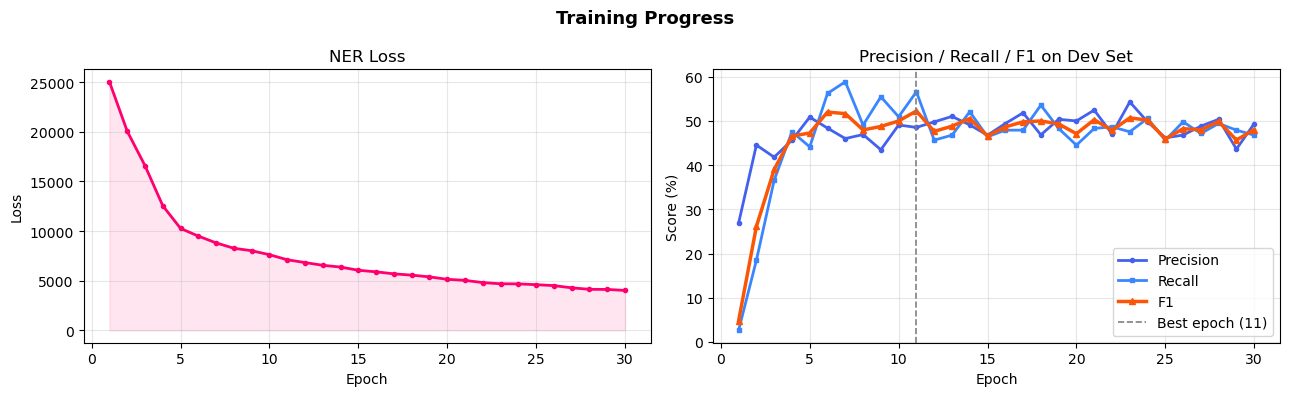

In [5]:
epochs = [h['epoch']     for h in history]
losses = [h['loss']      for h in history]
f1s    = [h['f1']        for h in history]
ps     = [h['precision'] for h in history]
rs     = [h['recall']    for h in history]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training Progress', fontweight='bold', fontsize=13)

axes[0].plot(epochs, losses, color=colors[2], linewidth=2, marker='o', markersize=3)
axes[0].fill_between(epochs, losses, alpha=0.1, color=colors[2])
axes[0].set_title('NER Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, ps,  color=colors[0], linewidth=2,   label='Precision', marker='o', markersize=3)
axes[1].plot(epochs, rs,  color=colors[1], linewidth=2,   label='Recall',    marker='s', markersize=3)
axes[1].plot(epochs, f1s, color=colors[3], linewidth=2.5, label='F1',        marker='^', markersize=4)
best_epoch = epochs[f1s.index(max(f1s))]
axes[1].axvline(best_epoch, color='gray', linestyle='--', linewidth=1.2,
                label=f'Best epoch ({best_epoch})')
axes[1].set_title('Precision / Recall / F1 on Dev Set')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()